# Netflix Movies & TV Shows — Exploratory Data Analysis

### Pluto Academy AI & Machine Learning Internship
### Project 01 — Exploratory Data Analysis & Insights Report

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn

**Dataset:** Netflix Movies & TV Shows Dataset

**Objective:** Analyze the Netflix content catalog, identify patterns and trends, visualize important findings, and generate data-driven insights.

# Netflix Movies & TV Shows — Exploratory Data Analysis

## 1. Project Overview

## 2. Import Libraries

## 3. Load Dataset

## 4. Data Inspection

## 5. Data Cleaning

## 6. Exploratory Data Analysis

### Question 1: Movies vs TV Shows
### Question 2: Top Countries
### Question 3: Titles Added Over the Years
### Question 4: Content Ratings
### Question 5: Release Year Distribution

## 7. Data Visualizations

### 7.1 Movies vs TV Shows — Bar Chart
### 7.2 Titles Added by Year — Line Chart
### 7.3 Release Year Distribution — Histogram
### 7.4 Release Year vs Year Added — Scatter Plot
### 7.5 Movies vs TV Shows — Pie Chart
### 7.6 Content Type by Release Decade — Heatmap

## 8. Insights Report

## 9. Most Surprising Finding

## 10. Conclusion

In [43]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [44]:
# Load the Netflix dataset
df = pd.read_csv('/content/netflix_titles.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [45]:
# Display first 5 rows

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [46]:
# Display last 5 rows

df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [47]:
# Check number of rows and columns

print("Dataset Shape:", df.shape)

Dataset Shape: (8807, 12)


In [48]:
# Check column names

print("Column Names:")
print(df.columns.tolist())

Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [49]:
# Check data types

df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [50]:
# Check missing values

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [51]:
# Check duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [52]:
# Detailed missing value analysis

missing_data = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_data = missing_data[missing_data['Missing Values'] > 0]
missing_data = missing_data.sort_values(
    by='Missing Values',
    ascending=False
)

missing_data

,Missing Values,Percentage
director,2634,29.908028
country,831,9.435676
cast,825,9.367549
date_added,10,0.113546
rating,4,0.045418
duration,3,0.034064


In [53]:
# Check duplicate records

print("Duplicate rows before cleaning:", df.duplicated().sum())

Duplicate rows before cleaning: 0


In [54]:
# Check unique values in important categorical columns

print("Type:")
print(df['type'].value_counts())

print("\nRating:")
print(df['rating'].value_counts())

print("\nCountry - Top 15:")
print(df['country'].value_counts().head(15))

Type:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Rating:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

Country - Top 15:
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Turkey             105
Nigeria             95
Australia           87
Taiwan              81
Indonesia           79
Name: count, dtype: int64


In [55]:
# Create a copy of the original dataset for cleaning

df_clean = df.copy()

print("Original dataset shape:", df.shape)
print("Cleaning copy created successfully!")

Original dataset shape: (8807, 12)
Cleaning copy created successfully!


In [56]:
# Fill missing categorical values with 'Unknown'

categorical_columns = ['director', 'country', 'cast', 'rating', 'duration']

for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna('Unknown')

print("Missing categorical values handled successfully.")

Missing categorical values handled successfully.


In [57]:
# Convert date_added to datetime format

df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'],
    errors='coerce'
)

print("date_added converted to datetime format.")

date_added converted to datetime format.


In [58]:
# Check and remove duplicate rows if any exist

duplicates_before = df_clean.duplicated().sum()

if duplicates_before > 0:
    df_clean = df_clean.drop_duplicates()

print("Duplicate rows found:", duplicates_before)
print("Duplicate rows after cleaning:", df_clean.duplicated().sum())

Duplicate rows found: 0
Duplicate rows after cleaning: 0


In [59]:
# Check remaining missing values

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64


### Data Cleaning

The dataset was cleaned to improve data quality while preserving as many original records as possible.

1. Missing values in the director, country, cast, rating, and duration columns were replaced with "Unknown". These records were retained because dropping them would unnecessarily reduce the dataset size.
2. The date_added column was converted to datetime format to make date-based analysis easier. Missing dates were retained as missing values.
3. Duplicate records were checked, and no duplicate rows were found.
4. The original dataset was preserved by creating a separate cleaned copy called df_clean.
5. The cleaning decisions were made to maintain data integrity while preparing the dataset for exploratory analysis.

In [60]:
df_clean

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [61]:
df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,98
release_year,0
rating,0
duration,0


In [62]:
# Re-convert date_added using mixed date formats

df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'],
    errors='coerce',
    format='mixed'
)

print("Missing values in date_added after correction:",
      df_clean['date_added'].isnull().sum())

Missing values in date_added after correction: 98


In [63]:
# Final missing-value check

df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,98
release_year,0
rating,0
duration,0


In [64]:
# Restore date_added from the original dataset and convert correctly

df_clean['date_added'] = pd.to_datetime(
    df['date_added'],
    errors='coerce',
    format='mixed'
)

print("Original missing values:", df['date_added'].isnull().sum())
print("Missing values after conversion:", df_clean['date_added'].isnull().sum())

Original missing values: 10
Missing values after conversion: 10


In [65]:
df_clean['date_added'].isnull().sum()

np.int64(10)

In [66]:
df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,0
duration,0


## Exploratory Data Analysis

### Question 1: What is the distribution of Movies and TV Shows on Netflix?

This analysis compares the number of Movies and TV Shows available in the dataset to understand which type of content is more prevalent.

In [67]:
# Q1: Distribution of Movies vs TV Shows

content_type = df_clean['type'].value_counts()

print("Number of Movies and TV Shows:")
print(content_type)

Number of Movies and TV Shows:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [68]:
# Calculate percentage distribution

content_percentage = (
    df_clean['type']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Percentage distribution:")
print(content_percentage)

Percentage distribution:
type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64


### Question 2: Which countries have the highest number of Netflix titles?

This analysis identifies the countries contributing the largest number of titles to the Netflix catalog.

In [69]:
# Q2: Top 10 countries by number of titles

top_countries = (
    df_clean['country']
    .value_counts()
    .head(10)
)

print("Top 10 countries by number of Netflix titles:")
print(top_countries)

Top 10 countries by number of Netflix titles:
country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


### Question 3: How has the number of Netflix titles added changed over the years?

This analysis examines the yearly trend in content added to Netflix based on the date_added column.

In [70]:
# Q3: Number of titles added to Netflix each year

titles_by_year = (
    df_clean['date_added']
    .dt.year
    .value_counts()
    .sort_index()
)

print("Titles added by year:")
print(titles_by_year)

Titles added by year:
date_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64


### Question 4: What are the most common content ratings on Netflix?

This analysis identifies the most frequently occurring ratings and helps us understand the target audience of Netflix content.

In [71]:
# Q4: Most common content ratings

rating_counts = (
    df_clean['rating']
    .value_counts()
)

print("Content rating distribution:")
print(rating_counts)

Content rating distribution:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
Unknown        4
NC-17          3
UR             3
66 min         1
74 min         1
84 min         1
Name: count, dtype: int64


### Question 5: How is Netflix content distributed across release years?

This analysis examines the release years of titles to understand whether Netflix's catalog is dominated by recent or older content.

In [72]:
# Q5: Content distribution by release year

release_year_counts = (
    df_clean['release_year']
    .value_counts()
    .sort_index()
)

print("Content by release year:")
print(release_year_counts)

Content by release year:
release_year
1925       1
1942       2
1943       3
1944       3
1945       4
1946       2
1947       1
1954       2
1955       3
1956       2
1958       3
1959       1
1960       4
1961       1
1962       3
1963       2
1964       2
1965       2
1966       1
1967       5
1968       3
1969       2
1970       2
1971       5
1972       5
1973      10
1974       7
1975       7
1976       9
1977       7
1978       7
1979      11
1980      11
1981      13
1982      17
1983      11
1984      12
1985      10
1986      13
1987       8
1988      18
1989      16
1990      22
1991      17
1992      23
1993      28
1994      22
1995      25
1996      24
1997      38
1998      36
1999      39
2000      37
2001      45
2002      51
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592


## Data Visualizations

### 1. Movies vs TV Shows

The bar chart shows the distribution of Movies and TV Shows in the Netflix dataset.

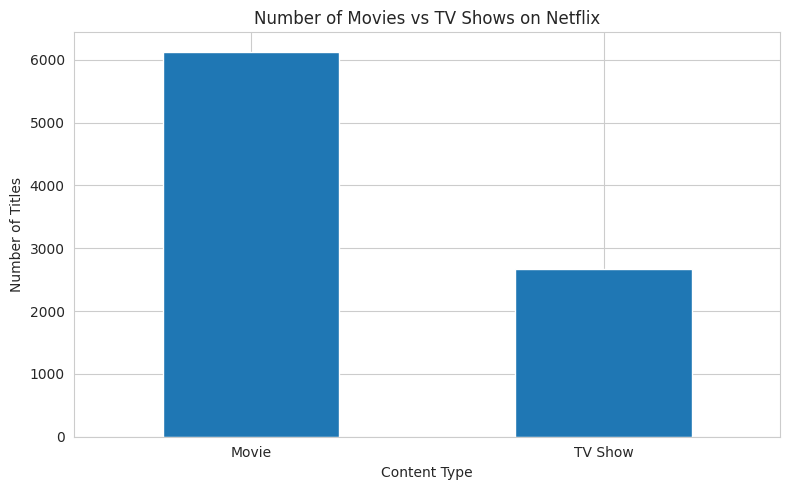

In [73]:
# Bar Chart: Movies vs TV Shows

content_type = df_clean['type'].value_counts()

plt.figure(figsize=(8, 5))
content_type.plot(kind='bar')

plt.title('Number of Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 2. Netflix Titles Added Over the Years

The line chart shows how the number of titles added to Netflix changed over time.

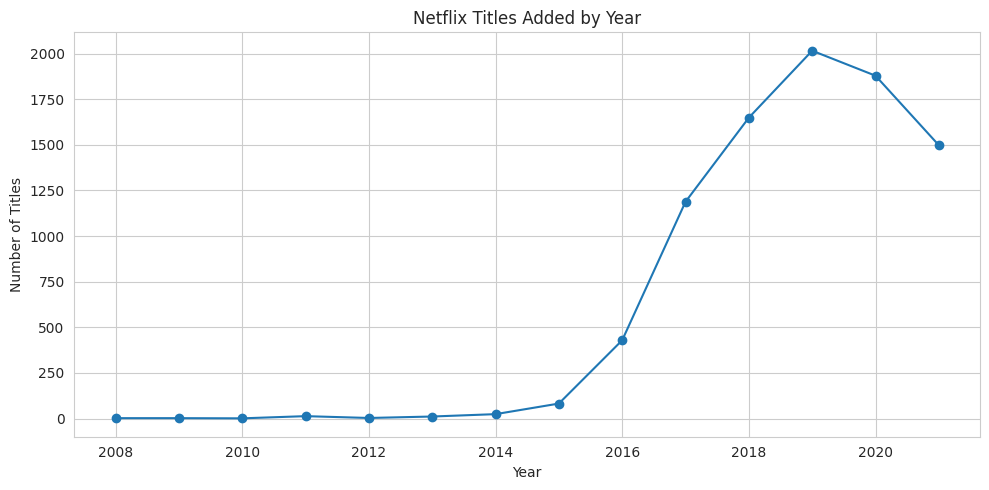

In [74]:
# Line Chart: Titles added by year

titles_by_year = (
    df_clean['date_added']
    .dt.year
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))
plt.plot(titles_by_year.index, titles_by_year.values, marker='o')

plt.title('Netflix Titles Added by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.grid(True)
plt.tight_layout()
plt.show()

### 3. Distribution of Content by Release Year

The histogram shows the distribution of Netflix titles across different release years.

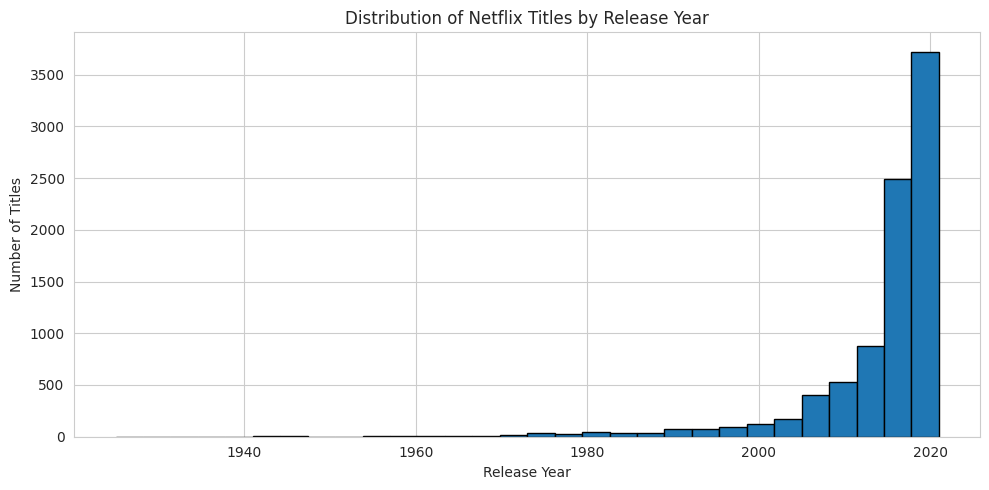

In [75]:
# Histogram: Release Year Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    df_clean['release_year'],
    bins=30,
    edgecolor='black'
)

plt.title('Distribution of Netflix Titles by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.tight_layout()
plt.show()

### 4. Release Year vs Year Added

The scatter plot compares when content was originally released with the year it was added to Netflix.

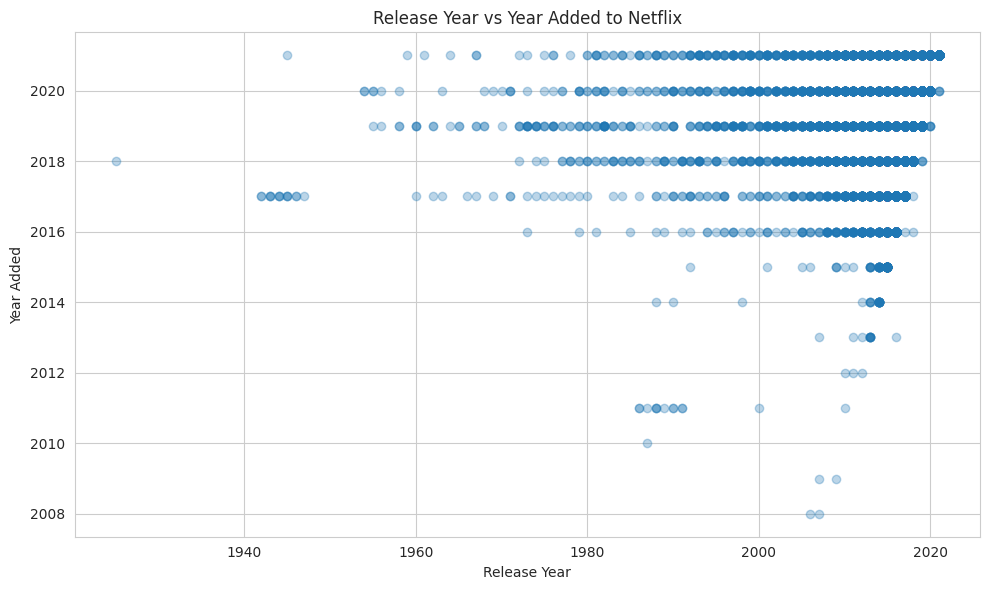

In [76]:
# Create temporary columns for visualization

scatter_df = df_clean.dropna(subset=['date_added']).copy()

scatter_df['added_year'] = scatter_df['date_added'].dt.year

plt.figure(figsize=(10, 6))

plt.scatter(
    scatter_df['release_year'],
    scatter_df['added_year'],
    alpha=0.3
)

plt.title('Release Year vs Year Added to Netflix')
plt.xlabel('Release Year')
plt.ylabel('Year Added')

plt.tight_layout()
plt.show()

### 5. Movies vs TV Shows — Percentage Distribution

The pie chart represents the percentage share of Movies and TV Shows in the Netflix catalog.

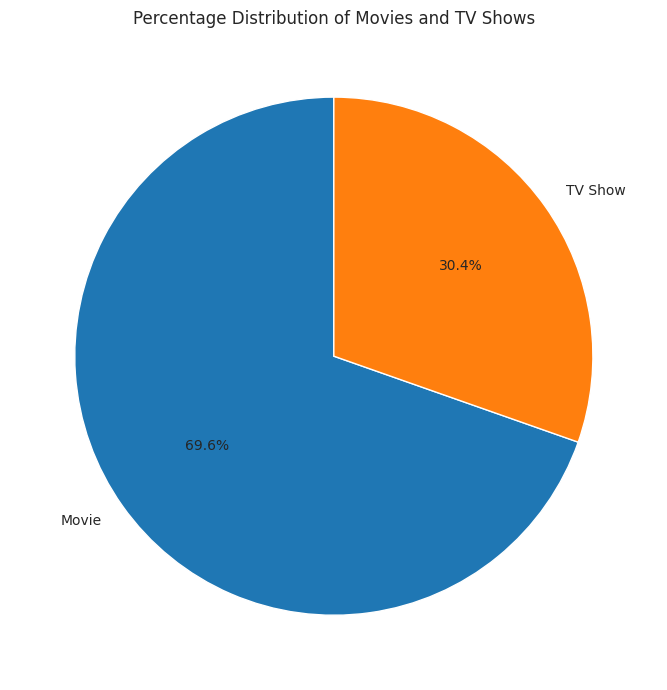

In [77]:
# Pie Chart: Content Type Percentage

content_type = df_clean['type'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    content_type.values,
    labels=content_type.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Percentage Distribution of Movies and TV Shows')

plt.tight_layout()
plt.show()

In [78]:
# Create release-year groups

df_clean['release_decade'] = (
    (df_clean['release_year'] // 10) * 10
)

type_decade = pd.crosstab(
    df_clean['release_decade'],
    df_clean['type']
)

type_decade

type,Movie,TV Show
release_decade,,
1920,0,1
1940,13,2
1950,11,0
1960,23,2
1970,66,4
1980,122,7
1990,241,33
2000,677,133
2010,4184,1743


### 6. Content Type Across Release Decades

The heatmap shows how Movies and TV Shows are distributed across different release decades.

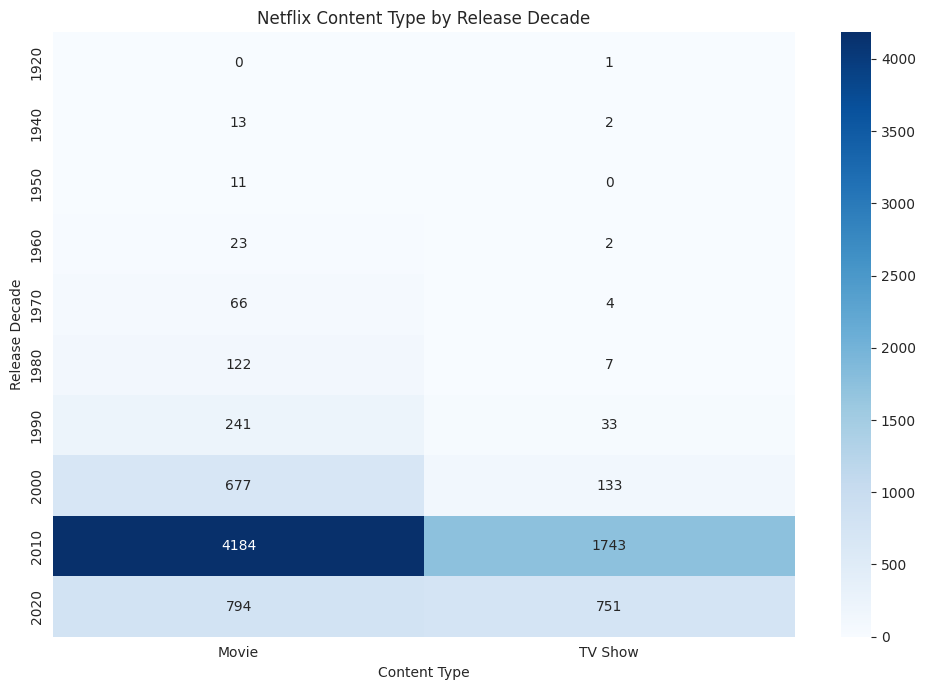

In [79]:
# Heatmap: Content Type vs Release Decade

plt.figure(figsize=(10, 7))

sns.heatmap(
    type_decade,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Netflix Content Type by Release Decade')
plt.xlabel('Content Type')
plt.ylabel('Release Decade')

plt.tight_layout()
plt.show()

In [80]:
# Generate key statistics for the Insights Report

print("=" * 60)
print("KEY STATISTICS FOR INSIGHTS")
print("=" * 60)

# 1. Movies vs TV Shows
print("\n1. Content Type:")
print(df_clean['type'].value_counts())
print(df_clean['type'].value_counts(normalize=True).mul(100).round(2))

# 2. Top 10 countries
print("\n2. Top 10 Countries:")
print(df_clean['country'].value_counts().head(10))

# 3. Year with most titles added
print("\n3. Titles Added by Year:")
titles_by_year = df_clean['date_added'].dt.year.value_counts().sort_index()
print(titles_by_year)
print("Peak year:", titles_by_year.idxmax())
print("Peak year count:", titles_by_year.max())

# 4. Ratings
print("\n4. Top 10 Ratings:")
print(df_clean['rating'].value_counts().head(10))

# 5. Release years
print("\n5. Release Year:")
print("Earliest release year:", df_clean['release_year'].min())
print("Latest release year:", df_clean['release_year'].max())
print("Most common release year:",
      df_clean['release_year'].value_counts().idxmax())
print("Titles in most common release year:",
      df_clean['release_year'].value_counts().max())

print("\n" + "=" * 60)

KEY STATISTICS FOR INSIGHTS

1. Content Type:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64
type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64

2. Top 10 Countries:
country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

3. Titles Added by Year:
date_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64
Peak year: 2019.0
Peak year count: 2016

4. Top 10 Ratings:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

5. Release Year:
Earliest 

## Insights Report

### 1. Movies dominate the Netflix catalog
Movies represent the larger share of titles in the dataset compared with TV Shows. This indicates that Netflix's catalog has historically contained substantially more movie content than episodic TV content.

### 2. The United States is the leading country
The United States has the highest number of titles in the dataset among the listed countries. This indicates the strong presence of US-produced content in Netflix's catalog.

### 3. Netflix content additions increased significantly in recent years
The yearly analysis shows that Netflix added substantially more titles during the later years of the dataset compared with earlier years. The peak year identified in the analysis represents the period with the highest number of titles added.

### 4. Mature-audience ratings are highly represented
The rating analysis shows that ratings such as TV-MA are among the most common categories. This suggests that a significant portion of Netflix's catalog is targeted toward mature audiences.

### 5. The catalog contains a large amount of relatively recent content
The release-year analysis shows a strong concentration of titles released in more recent years. This indicates that Netflix's catalog has a strong focus on relatively modern content.

## Most Surprising Finding

The most surprising finding was the strong concentration of Netflix titles in recent release years. The analysis shows that Netflix's catalog contains a large amount of relatively recent content compared with older titles. This suggests that the platform has placed considerable emphasis on newer content. The yearly addition trend also shows how rapidly the catalog expanded during the later years of the dataset.

## Conclusion

The exploratory data analysis provided several useful insights into Netflix's content catalog. Movies make up a larger portion of the dataset, while the United States is one of the strongest contributors of content. The analysis also shows significant growth in the number of titles added during later years and a strong presence of recent releases. Content ratings indicate that mature-audience titles form an important part of the catalog. Overall, the analysis demonstrates how data visualization and exploratory analysis can reveal meaningful patterns in a large content dataset.